In [ ]:
import jax
import equinox as eqx
import jax.random as jrandom
from diff_ml.reference_models.analytic import Analytic
from diff_ml.reference_models.bachelier import Bachelier
from diff_ml.reference_models.heston import Heston
from diff_ml.reference_models.mnist import MNIST_ref
from diff_ml.nn.utils import init_linear_weight, trunc_init
import optax
from diff_ml.nn.train import train

from diff_ml.utils import Range, MakeScalar, mse

from jax import vmap
import jax.numpy as jnp

from diff_ml.losses.directions import StreamingHessianSketch

import matplotlib.pyplot as plt

# style changes for latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 12
})

In [ ]:
def make_MNIST(key, test_set_order=2):
    ref_model = MNIST_ref(
        key=key, 
        scale=0.5,
        target_class=9
    )
    test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    return ref_model, test_set
    

def make_bachelier(key, test_set_order):
    basket_dim = 7
    n_paths = 0 # number of MC paths per label. Set to 0 to use analytic formula.
    ref_model = Bachelier(
        subkey,
        basket_dim=basket_dim, 
        weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0),
        n_paths_per_label=n_paths
    )
    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

def make_heston(key, test_set_order, do_test_eval=True):
    basket_dim = 7
    ref_model = Heston(
        key = key,
        basket_dim=basket_dim,
        basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    if not do_test_eval:
        test_set = None
    else:
        if test_set_order ==3:
            test_set = ref_model.get_test_set(n_samples=1*128, order=test_set_order)
        else:
            test_set = ref_model.get_test_set(n_samples=1*1024, order=test_set_order)
    return ref_model, test_set
    
def make_analytic(key, test_set_order):
    min_x, max_x, type = -5.0, 5.0, "RHE"
    #min_x, max_x, type = -1.0, 1.0, "CubicRankR"
    #min_x, max_x, type = -1.5, 2.5, "Rosenbrock"
    #min_x, max_x, type = -5.0, 5.0, "Ackley"
    #min_x, max_x, type = -5.12, 5.12, "Rastrigin"
    ref_model = Analytic(
        key=key,
        type=type,
        d=20,
        min_x=min_x,
        max_x=max_x
    )
    test_set = ref_model.get_test_set(n_samples=2*1024, order=test_set_order)
    return ref_model, test_set

## RMSE curves plot

In [ ]:
main_key = jrandom.PRNGKey(42)

# averaging over n seeds
n_runs = 10

n_epochs = 100
n_batches_per_epoch = 64#512#64#64#32#32#8#32 # 32
batch_size = 128#16#128#16#256#16 #256 # 256

lr = 1e-3

k = 1
streaming_r = 2
power_iteration_q = 0

oversamppling_p = streaming_r - k

test_set_order = 3
learnable_loss_weights = False
do_approx_metrics = False # set to False for accurate time per batch measurement
do_test_eval = True



#ref_model, test_set = make_MNIST(main_key, test_set_order=2)

data = {}
for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian", "3rdBatchSVD"]:
    print("running variant", variant)
    
    test_losses_values = []
    test_losses_grads = []
    test_losses_hessians = []
    test_losses_t3s = []
    avg_times = []
 

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")
        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key, test_set_order)
        #ref_model, test_set = make_heston(key, do_test_eval, test_set_order)
        #ref_model, test_set = make_analytic(key, test_set_order)
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        ref_model=ref_model,
                        r=streaming_r,
                        k=k, 
                        key=subkey)
        
        optim = optax.adam(learning_rate=lr)
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=batch_size,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k,
                                p=oversamppling_p,
                                q=power_iteration_q,
                                learnable_loss_weights=learnable_loss_weights,
                                do_approx_metrics=do_approx_metrics,
                                do_test_eval=do_test_eval
                                )
        
        test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
        test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
        test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
        test_losses_t3 = jnp.array([iteration_datas[t]["test t3 loss"] for t in range(len(iteration_datas))])
        #test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
        #train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])
    
        test_losses_values.append(test_losses_value)
        test_losses_grads.append(test_losses_grad)
        test_losses_hessians.append(test_losses_hess)
        test_losses_t3s.append(test_losses_t3)
        avg_times.append(avg_time_per_batch)

        

    # average the runs
    print("")
    test_losses_values = jnp.array(test_losses_values)
    test_losses_grads = jnp.array(test_losses_grads)
    test_losses_hessians = jnp.array(test_losses_hessians)
    test_losses_t3s = jnp.array(test_losses_t3s)

    test_losses_values_mean = test_losses_values.mean(axis=0)
    test_losses_values_std = test_losses_values.std(axis=0)
    test_losses_grads_mean = test_losses_grads.mean(axis=0)
    test_losses_grads_std = test_losses_grads.std(axis=0)
    test_losses_hessians_mean = test_losses_hessians.mean(axis=0)
    test_losses_hessians_std = test_losses_hessians.std(axis=0)
    test_losses_t3s_mean = test_losses_t3s.mean(axis=0)
    test_losses_t3s_std = test_losses_t3s.std(axis=0)

    avg_times_mean = jnp.mean(jnp.array(avg_times))
    print(f"Average time per batch for variant {variant}: {avg_times_mean:.5f}s")

    data[variant] = {
        "test_losses_values": (test_losses_values_mean, test_losses_values_std),
        "test_losses_grads": (test_losses_grads_mean, test_losses_grads_std),
        "test_losses_hessians": (test_losses_hessians_mean, test_losses_hessians_std),
        "test_losses_t3s": (test_losses_t3s_mean, test_losses_t3s_std),
        "avg_time_per_batch": avg_times_mean
    }

running variant value

run 1 / 10 for value
Training for 100 epochs with 64 batches per epoch and batch size 128.
Finished epoch 1 | Train Loss: 1.00983 | Test Value Loss: 0.99998
Finished epoch 2 | Train Loss: 0.88216 | Test Value Loss: 0.93886
Finished epoch 3 | Train Loss: 0.88241 | Test Value Loss: 0.89340
Finished epoch 4 | Train Loss: 0.84533 | Test Value Loss: 0.84814
Finished epoch 5 | Train Loss: 0.75453 | Test Value Loss: 0.80371
Finished epoch 6 | Train Loss: 0.65899 | Test Value Loss: 0.75970
Finished epoch 7 | Train Loss: 0.56719 | Test Value Loss: 0.71558
Finished epoch 8 | Train Loss: 0.47977 | Test Value Loss: 0.67493
Finished epoch 9 | Train Loss: 0.40339 | Test Value Loss: 0.64098
Finished epoch 10 | Train Loss: 0.34271 | Test Value Loss: 0.61251
Finished epoch 11 | Train Loss: 0.29527 | Test Value Loss: 0.58723
Finished epoch 12 | Train Loss: 0.26063 | Test Value Loss: 0.56485
Finished epoch 13 | Train Loss: 0.23878 | Test Value Loss: 0.54662
Finished epoch 14 | Trai

In [ ]:
# print out final errors and std deviations

for variant in data.keys():
    print(f"Variant: {variant}")
    avg_time = data[variant]["avg_time_per_batch"]
    print(f"  avg time per batch: {avg_time*1000:.2f} ms")
    
    for order, name in zip(
        ["test_losses_values", "test_losses_grads", "test_losses_hessians", "test_losses_t3s"],
        ["value", "1st-order", "2nd-order", "3rd-order"]
    ):
        final_loss_mean, final_loss_std = data[variant][order]
        final_loss_mean = final_loss_mean[-1]
        final_loss_std = final_loss_std[-1]
        print(f"  final {name} loss: {final_loss_mean:.6f} ± {final_loss_std:.6f}")
    print("")

Variant: value
  avg time per batch: 1.40 ms
  final value loss: 0.364943 ± 0.008678
  final 1st-order loss: 0.962324 ± 0.014992
  final 2nd-order loss: 3.930733 ± 0.061215
  final 3rd-order loss: 16.359432 ± 0.251021

Variant: 1st
  avg time per batch: 2.11 ms
  final value loss: 0.395858 ± 0.009046
  final 1st-order loss: 0.959865 ± 0.014885
  final 2nd-order loss: 3.930785 ± 0.061196
  final 3rd-order loss: 16.359434 ± 0.251026

Variant: random
  avg time per batch: 2.38 ms
  final value loss: 0.399614 ± 0.014591
  final 1st-order loss: 0.960069 ± 0.014943
  final 2nd-order loss: 3.930775 ± 0.061190
  final 3rd-order loss: 16.359421 ± 0.251028

Variant: pcady
  avg time per batch: 2.49 ms
  final value loss: 0.403389 ± 0.011702
  final 1st-order loss: 0.960051 ± 0.014911
  final 2nd-order loss: 3.930782 ± 0.061196
  final 3rd-order loss: 16.359413 ± 0.251019

Variant: batchSVD
  avg time per batch: 2.52 ms
  final value loss: 0.397617 ± 0.014849
  final 1st-order loss: 0.960367 ± 0.

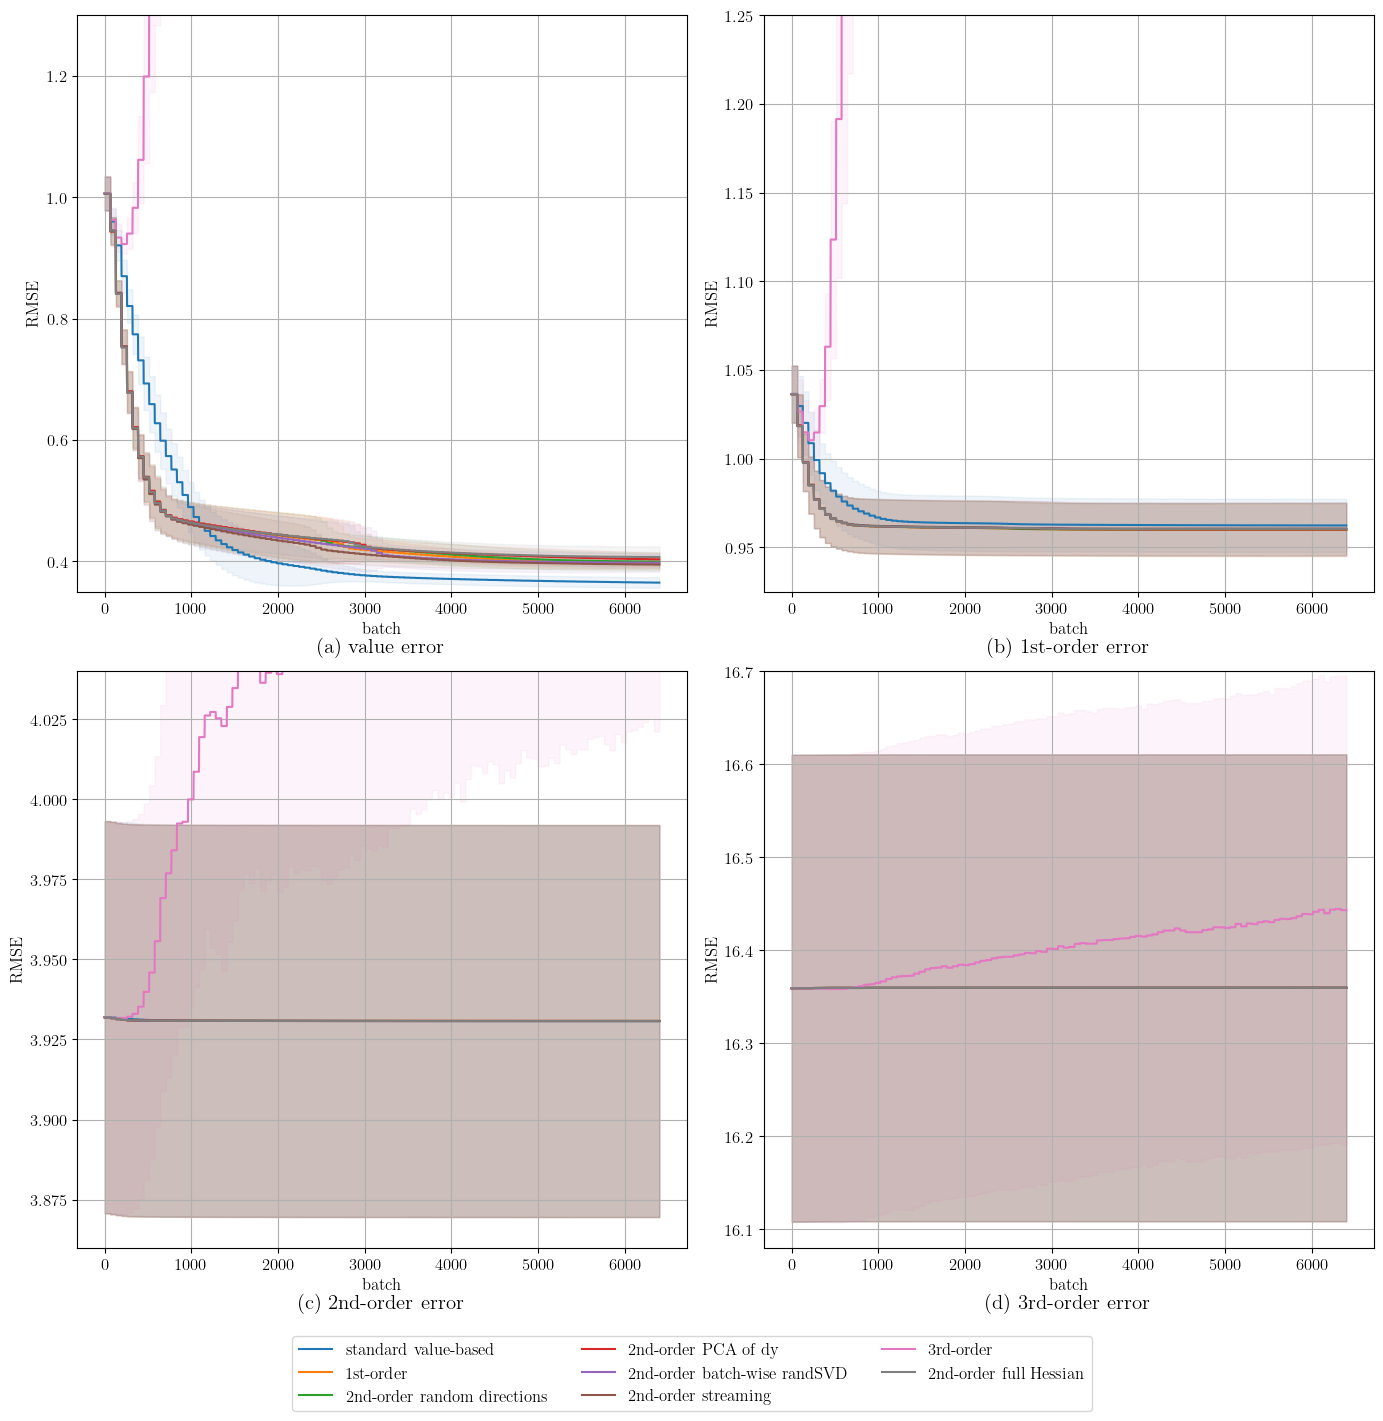

In [ ]:
# plot the RMSE curves

import matplotlib.pyplot as plt
from matplotlib import cm

colors = cm.tab10.colors
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)


over_time = False


batch_cap = -1

orders = ["values", "grads", "hessians", "t3s"]

order_names = {
    "values": "(a) value",
    "grads": "(b) 1st-order",
    "hessians": "(c) 2nd-order",
    "t3s": "(d) 3rd-order"
}

order_ylims = {
    "values": (0.0, 1.0),
    "grads": (0.0, 1.0),
    "hessians": (0.0, 1.0),
    "t3s": (0.0, 1.0)
}

variant_names = {
    "value": "standard value-based",
    "1st": "1st-order",
    "random": "2nd-order random directions",
    "pcady": "2nd-order PCA of dy",
    "batchSVD": "2nd-order batch-wise randSVD",
    "streaming": "2nd-order streaming",
    "fullHessian": "2nd-order full Hessian",
    "3rdBatchSVD": "3rd-order"
}

variants = ["value", "1st", "random", "pcady", "batchSVD", "streaming", "3rdBatchSVD", "fullHessian"]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

handles = []  # for collecting legend entries

for ax, order in zip(axes, orders):
    
    for variant in variants:
        results = data[variant]

        mean = results[f"test_losses_{order}"][0][:batch_cap]
        std  = results[f"test_losses_{order}"][1][:batch_cap]
        x = jnp.array(range(len(mean)))

        if over_time:
            time_per_batch = results["avg_time_per_batch"]
            # Scale x-axis by execution time
            x = x * time_per_batch

        # plot line
        line, = ax.plot(x, mean, label=variant_names[variant])

        # shaded std band
        ax.fill_between(
            x, mean - std, mean + std,
            color=line.get_color(),
            alpha=0.075
        )

        # Store handle for legend only once
        if order == "values":
            handles.append(line)

    ax.set_title(f"{order_names[order]} error", y=-0.12, fontsize=15)
    x_label = "execution time (s)" if over_time else "batch"
    ax.set_xlabel(x_label)
    ax.set_ylabel("RMSE")
    
    #ax.set_ylim(*order_ylims[order])
    ax.grid(True)
    

# Shared legend under all plots
fig.legend(
    handles,
    [variant_names[v] for v in variants],
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=(0, 0.05, 1, 1))
#axes[-1].set_visible(False)
plt.show()


In [ ]:
import time
now = time.strftime("%d_%m_%H_%M")
fig.savefig(f"res/losses_bachelier7analytic_k{k}_r{r}_q{q}_{n_batches_per_epoch}_{batch_size}_lb_{now}.pdf", bbox_inches='tight')